# DSA 4060 – Week 1 Practical: Popularity-Based Movie Recommender

**Course:** DSA 4060 Recommender Systems  
**Name:** Hans Onesmo
**ID:** 671463

**Purpose.** Build a non-personalized recommender on the MovieLens latest-small dataset. The notebook validates the data, explores user–item interactions, builds a minimum-ratings popularity baseline and a weighted-rating baseline, tests the outputs, and discusses their limitations. Every user receives the same ranked list, which gives a transparent baseline for later personalized models.

## 1. Import Libraries

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 2. Define File Paths
The notebook lives in `notebooks/`, so `..` is the project root. On Colab, change `PROJECT_ROOT` to the folder where you uploaded the files (e.g. `Path('/content')` with the CSVs in `/content/data`).

In [ ]:
PROJECT_ROOT = Path('/content')
DATA_DIR = PROJECT_ROOT
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / 'movies.csv'
RATINGS_FILE = DATA_DIR / 'ratings.csv'

## 3. Load the CSV Files

In [ ]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (87585, 3)
Ratings shape: (936171, 4)


## 4. Preview and Inspect
Expected columns: `movieId, title, genres` in movies and `userId, movieId, rating, timestamp` in ratings.

In [ ]:
display(movies.head())
display(ratings.head())
movies.info()
ratings.info()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077.0
1,1,25,1.0,944250228.0
2,1,29,2.0,943230976.0
3,1,30,5.0,944249077.0
4,1,32,5.0,943228858.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936171 entries, 0 to 936170
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     936171 non-null  int64  
 1   movieId    936171 non-null  int64  
 2   rating     936170 non-null  float64
 3   timestamp  936170 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 28.6 MB


In [ ]:
assert {'movieId', 'title', 'genres'} <= set(movies.columns)
assert {'userId', 'movieId', 'rating', 'timestamp'} <= set(ratings.columns)
print('Column check passed.')

Column check passed.


## 5. Validate the Data

In [ ]:
print('Missing values in movies:')
print(movies.isna().sum())
print('\nMissing values in ratings:')
print(ratings.isna().sum())
print('\nDuplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())
print('Unknown movie IDs:', (~ratings['movieId'].isin(movies['movieId'])).sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       1
timestamp    1
dtype: int64

Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


In [ ]:
# A record is identified by (userId, movieId): one user should rate a movie once.
dup_keys = ratings.duplicated(subset=['userId', 'movieId']).sum()
dup_movie_ids = movies['movieId'].duplicated().sum()
print('Repeated (userId, movieId) pairs:', dup_keys)
print('Repeated movieId values in movies.csv:', dup_movie_ids)

Repeated (userId, movieId) pairs: 0
Repeated movieId values in movies.csv: 0


**Interpretation.** The validation checks show whether either file has missing values, fully duplicated rows, ratings outside the expected 0.5–5.0 scale, or ratings that point to movies absent from `movies.csv`. Because I defined a record by `(userId, movieId)` for ratings and by `movieId` for movies, the two key-based duplicate counts are the relevant ones: if both are zero, no rows need to be removed and the later `one_to_one` merge is safe. No rows were dropped merely because a generic duplicate count was nonzero.

## 6. Summarize the Interaction Data

In [ ]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
n_interactions = len(ratings)

print('Unique users:', n_users)
print('Movies with at least one rating:', n_movies_rated)
print('Movies listed in movies.csv:', movies['movieId'].nunique())
print('Total rating interactions:', n_interactions)
print(ratings['rating'].describe())

Unique users: 6127
Movies with at least one rating: 25644
Movies listed in movies.csv: 87585
Total rating interactions: 936171
count    936170.000000
mean          3.569918
std           1.056105
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


**What the numbers mean.**
- **Unique users** – distinct people (`userId`) who gave at least one rating.
- **Movies with at least one rating** – items that have any interaction data. This can be smaller than the number of movies in `movies.csv`; unrated movies cannot be scored by a ratings-based method.
- **Total rating interactions** – the number of rows in `ratings.csv`, each a single explicit user–item rating.
- **`describe()` on rating** – count, mean, spread and quartiles of the explicit feedback on the 0.5–5.0 scale.

## 7. Explore User–Item Interactions
### 7.1 Ratings per user and per movie

In [ ]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print('Ratings per user:')
print(ratings_per_user.describe())
print()
print('Ratings per movie:')
print(ratings_per_movie.describe())

Ratings per user:
count    6127.000000
mean      152.794353
std       241.834637
min         3.000000
25%        36.000000
50%        72.000000
75%       161.000000
max      3893.000000
dtype: float64

Ratings per movie:
count    25644.000000
mean        36.506434
std        138.197967
min          1.000000
25%          1.000000
50%          2.000000
75%         13.000000
max       3166.000000
dtype: float64


**Reading the summaries.** Compare the median with the mean and maximum in each table. A mean well above the median indicates a right-skewed distribution: a few very active users and a few very widely rated movies alongside a long tail of sparsely rated ones.

### 7.2 Rating distribution

rating
0.5     15317
1.0     26949
1.5     14584
2.0     57220
2.5     45079
3.0    172466
3.5    123699
4.0    251480
4.5     89430
5.0    139946
Name: count, dtype: int64


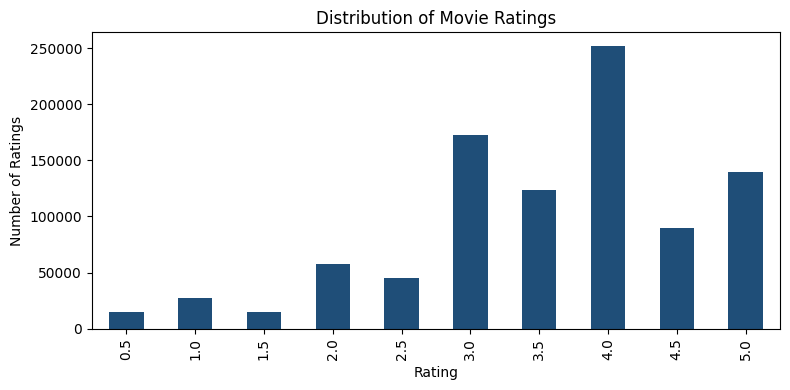

In [ ]:
rating_distribution = ratings['rating'].value_counts().sort_index()
print(rating_distribution)

ax = rating_distribution.plot(kind='bar', color='#1F4E78', figsize=(8, 4))
ax.set_title('Distribution of Movie Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

In [ ]:
most_common = rating_distribution.idxmax()
share_low = (ratings['rating'] <= 2.0).mean()
print(f'Most frequent rating: {most_common}')
print(f'Share of ratings at 2.0 or below: {share_low:.1%}')

Most frequent rating: 4.0
Share of ratings at 2.0 or below: 12.2%


**Interpretation.** The chart establishes which rating value occurs most often and how common low ratings (2.0 and below) are, using the two figures printed above. It does not explain *why* users rate this way, so no cause is claimed.

### 7.3 Interaction matrix sparsity

In [ ]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)

print(f'Possible interactions: {possible_interactions:,}')
print(f'Observed interactions: {observed_interactions:,}')
print(f'Sparsity: {sparsity:.2%}')

Possible interactions: 157,120,788
Observed interactions: 936,171
Sparsity: 99.40%


**Interpretation.** Sparsity is the share of user–movie cells in the full matrix that have no rating. A high value means each user has rated only a tiny fraction of the catalogue, so preferences must be inferred from very limited observations. The popularity baseline built next does not try to fill these empty cells; it ignores who the user is.

## 8. Build a Popularity Recommender
### 8.1 Aggregate ratings by movie

In [ ]:
movie_stats = (
    ratings.groupby('movieId')
    .agg(average_rating=('rating', 'mean'),
         rating_count=('rating', 'count'))
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[['movieId', 'title', 'genres']],
    on='movieId',
    how='left',
    validate='one_to_one'
)
display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.900765,2091,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.269851,806,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.217678,379,Grumpier Old Men (1995),Comedy|Romance
3,4,2.706250,80,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.059322,354,Father of the Bride Part II (1995),Comedy


`validate='one_to_one'` makes the merge fail if either side has duplicate movie IDs, which is safer than silently multiplying rows.

### 8.2 Most rated movies

In [ ]:
most_rated = (
    movie_stats.sort_values(['rating_count', 'average_rating'], ascending=[False, False])
    .head(10)
)
display(most_rated[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
308,"Shawshank Redemption, The (1994)",3166,4.422457
345,Forrest Gump (1994),3053,4.043236
286,Pulp Fiction (1994),3042,4.221236
2352,"Matrix, The (1999)",2871,4.171021
572,"Silence of the Lambs, The (1991)",2745,4.172860
251,Star Wars: Episode IV - A New Hope (1977),2610,4.121264
2718,Fight Club (1999),2313,4.250757
465,Jurassic Park (1993),2286,3.735564
1098,Star Wars: Episode V - The Empire Strikes Back...,2208,4.155344
4594,"Lord of the Rings: The Fellowship of the Ring,...",2203,4.086019


This list reflects **visibility / engagement**, not necessarily quality: a widely rated movie can still have a moderate average.

### 8.3 Highest average ratings

In [ ]:
highest_average = (
    movie_stats.sort_values(['average_rating', 'rating_count'], ascending=[False, False])
    .head(10)
)
display(highest_average[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
1053,"Line King: The Al Hirschfeld Story, The (1996)",5,5.0
12384,Outrageous Class (Hababam sinifi) (1975),3,5.0
12387,"Crazy Class Wakes Up, The (Hababam sinifi uyan...",3,5.0
15791,The Chaos Class Failed the Class (1976),3,5.0
738,"Unforgettable Summer, An (Un été inoubliable) ...",2,5.0
740,My Life and Times With Antonin Artaud (En comp...,2,5.0
743,"Old Lady Who Walked in the Sea, The (Vieille q...",2,5.0
817,1-900 (06) (1994),2,5.0
886,Angel on My Shoulder (1946),2,5.0
1640,Follow the Bitch (1996),2,5.0


In [ ]:
print('Median rating_count in the highest-average Top 10:', highest_average['rating_count'].median())
print('Median rating_count across all movies:', movie_stats['rating_count'].median())

Median rating_count in the highest-average Top 10: 2.0
Median rating_count across all movies: 2.0


**Why average alone misleads.** Inspect `rating_count` above: movies with only a handful of ratings can reach a perfect or near-perfect mean by chance. One five-star rating gives a mean of 5.0, but that is weak evidence of broad appeal. Ranking by average alone therefore rewards small samples.

### 8.4 Minimum-ratings baseline
A movie must have at least 50 ratings before it is ranked by average rating. The threshold of 50 is a teaching choice, not a universal rule.

In [ ]:
MIN_RATINGS = 50

popular_movies = (
    movie_stats[movie_stats['rating_count'] >= MIN_RATINGS]
    .sort_values(['average_rating', 'rating_count'], ascending=[False, False])
    .head(10)
)
display(popular_movies[['title', 'genres', 'rating_count', 'average_rating']])

,title,genres,rating_count,average_rating
19689,Planet Earth II (2016),Documentary,63,4.579365
19642,Band of Brothers (2001),Action|Drama|War,84,4.482143
18597,Planet Earth (2006),Documentary,99,4.459596
308,"Shawshank Redemption, The (1994)",Crime|Drama,3166,4.422457
22418,Parasite (2019),Comedy|Drama,346,4.351156
792,"Godfather, The (1972)",Crime|Drama,2026,4.312438
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2069,4.301112
18916,Your Name. (2016),Animation|Drama|Fantasy|Romance,110,4.286364
1105,12 Angry Men (1957),Drama,668,4.282186
1122,"Godfather: Part II, The (1974)",Crime|Drama,1299,4.269053


### 8.5 Convert the logic into a function

In [ ]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    candidates = stats[stats['rating_count'] >= min_ratings].copy()
    return (
        candidates.sort_values(['average_rating', 'rating_count'], ascending=[False, False])
        .head(top_n)
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
    )

recommendations = recommend_popular_movies(movie_stats, 50, 10)
display(recommendations)

,movieId,title,genres,rating_count,average_rating
19689,171011,Planet Earth II (2016),Documentary,63,4.579365
19642,170705,Band of Brothers (2001),Action|Drama|War,84,4.482143
18597,159817,Planet Earth (2006),Documentary,99,4.459596
308,318,"Shawshank Redemption, The (1994)",Crime|Drama,3166,4.422457
22418,202439,Parasite (2019),Comedy|Drama,346,4.351156
792,858,"Godfather, The (1972)",Crime|Drama,2026,4.312438
49,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2069,4.301112
18916,163134,Your Name. (2016),Animation|Drama|Fantasy|Romance,110,4.286364
1105,1203,12 Angry Men (1957),Drama,668,4.282186
1122,1221,"Godfather: Part II, The (1974)",Crime|Drama,1299,4.269053


## 9. Build a Weighted-Rating Baseline
### 9.1 Why a weighted score
A hard threshold discards every movie below the cutoff. A weighted rating instead shrinks the average of low-count movies toward the overall mean, while movies with many ratings mostly keep their own average:

**weighted score = (v / (v + m)) × R + (m / (v + m)) × C**

where *R* = movie average, *v* = its rating count, *C* = overall mean rating, *m* = minimum evidence threshold.

### 9.2 Select the threshold

In [ ]:
C = ratings['rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)

print(f'Overall mean rating C: {C:.3f}')
print(f'90th percentile rating count m: {m:.1f}')

Overall mean rating C: 3.570
90th percentile rating count m: 69.0


Using the 90th percentile means only movies in roughly the top 10% by rating count qualify. This is a transparent policy choice, tested against other percentiles in section 9.4.

### 9.3 Calculate weighted scores

In [ ]:
qualified = movie_stats[movie_stats['rating_count'] >= m].copy()
v = qualified['rating_count']
R = qualified['average_rating']

qualified['weighted_score'] = (v / (v + m)) * R + (m / (v + m)) * C

weighted_top10 = (
    qualified.sort_values(['weighted_score', 'rating_count'], ascending=[False, False])
    .head(10)
    [['movieId', 'title', 'genres', 'rating_count', 'average_rating', 'weighted_score']]
    .reset_index(drop=True)
)
weighted_top10.index += 1
display(weighted_top10)

,movieId,title,genres,rating_count,average_rating,weighted_score
1,318,"Shawshank Redemption, The (1994)",Crime|Drama,3166,4.422457,4.404273
2,858,"Godfather, The (1972)",Crime|Drama,2026,4.312438,4.287983
3,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2069,4.301112,4.277514
4,1221,"Godfather: Part II, The (1974)",Crime|Drama,1299,4.269053,4.233790
5,2959,Fight Club (1999),Action|Crime|Drama|Thriller,2313,4.250757,4.231035
6,527,Schindler's List (1993),Drama|War,2201,4.248751,4.228116
7,202439,Parasite (2019),Comedy|Drama,346,4.351156,4.221264
8,1203,12 Angry Men (1957),Drama,668,4.282186,4.215501
9,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,3042,4.221236,4.206790
10,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,985,4.237563,4.193856


In [ ]:
def recommend_weighted_movies(stats, overall_mean, percentile=0.90, top_n=10):
    m_ = stats['rating_count'].quantile(percentile)
    cand = stats[stats['rating_count'] >= m_].copy()
    v_, R_ = cand['rating_count'], cand['average_rating']
    cand['weighted_score'] = (v_ / (v_ + m_)) * R_ + (m_ / (v_ + m_)) * overall_mean
    return (
        cand.sort_values(['weighted_score', 'rating_count'], ascending=[False, False])
        .head(top_n)
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating', 'weighted_score']]
    )

### 9.4 Test a different percentile
How does the candidate pool change with the threshold?

In [ ]:
rows = []
for p in [0.50, 0.75, 0.90, 0.95]:
    m_p = movie_stats['rating_count'].quantile(p)
    pool = int((movie_stats['rating_count'] >= m_p).sum())
    top = recommend_weighted_movies(movie_stats, C, p, 10)
    rows.append({'percentile': p, 'm (min ratings)': round(m_p, 1),
                 'candidate pool': pool, 'top-1 movie': top.iloc[0]['title']})
display(pd.DataFrame(rows))

overlap90 = set(recommend_weighted_movies(movie_stats, C, 0.90)['movieId'])
overlap75 = set(recommend_weighted_movies(movie_stats, C, 0.75)['movieId'])
print('Top-10 overlap between 75th and 90th percentile lists:', len(overlap90 & overlap75), 'of 10')

,percentile,m (min ratings),candidate pool,top-1 movie
0,0.50,2.0,15827,"Line King: The Al Hirschfeld Story, The (1996)"
1,0.75,13.0,6556,"Shawshank Redemption, The (1994)"
2,0.90,69.0,2574,"Shawshank Redemption, The (1994)"
3,0.95,173.8,1283,"Shawshank Redemption, The (1994)"


Top-10 overlap between 75th and 90th percentile lists: 6 of 10


**Interpretation.** A lower percentile lowers *m*, admitting more movies into the pool (less evidence required); a higher percentile shrinks the pool to only heavily rated titles. Read the table above: the candidate pool size falls as the percentile rises, and the overlap count shows how sensitive the final Top 10 is to this policy choice.

### 9.5 Compare the three methods

In [ ]:
compare = pd.concat({
    'Most rated': most_rated['title'].reset_index(drop=True),
    'Min 50 ratings, by average': popular_movies['title'].reset_index(drop=True),
    'Weighted rating (90th pct)': weighted_top10['title'].reset_index(drop=True),
}, axis=1)
compare.index = compare.index + 1
display(compare)

print('Overlap (min-50 list vs weighted list):',
      len(set(popular_movies['movieId']) & set(weighted_top10['movieId'])), 'of 10')

,Most rated,"Min 50 ratings, by average",Weighted rating (90th pct)
1,"Shawshank Redemption, The (1994)",Planet Earth II (2016),"Shawshank Redemption, The (1994)"
2,Forrest Gump (1994),Band of Brothers (2001),"Godfather, The (1972)"
3,Pulp Fiction (1994),Planet Earth (2006),"Usual Suspects, The (1995)"
4,"Matrix, The (1999)","Shawshank Redemption, The (1994)","Godfather: Part II, The (1974)"
5,"Silence of the Lambs, The (1991)",Parasite (2019),Fight Club (1999)
6,Star Wars: Episode IV - A New Hope (1977),"Godfather, The (1972)",Schindler's List (1993)
7,Fight Club (1999),"Usual Suspects, The (1995)",Parasite (2019)
8,Jurassic Park (1993),Your Name. (2016),12 Angry Men (1957)
9,Star Wars: Episode V - The Empire Strikes Back...,12 Angry Men (1957),Pulp Fiction (1994)
10,"Lord of the Rings: The Fellowship of the Ring,...","Godfather: Part II, The (1974)",Dr. Strangelove or: How I Learned to Stop Worr...


Overlap (min-50 list vs weighted list): 6 of 10


## 10. Test the Output

In [ ]:
# Automated sanity checks on the recommender outputs
assert len(weighted_top10) == 10, 'Expected 10 recommendations'
assert weighted_top10['movieId'].is_unique, 'Duplicate movies in Top 10'
assert weighted_top10['weighted_score'].is_monotonic_decreasing, 'List not ranked'
assert (weighted_top10['rating_count'] >= m).all(), 'Movie below evidence threshold'
assert weighted_top10['title'].notna().all(), 'Missing titles'
assert (recommendations['rating_count'] >= 50).all(), 'Min-ratings rule violated'
assert recommendations['average_rating'].between(0.5, 5.0).all()

# Shrinkage property: weighted score lies between the movie average and the overall mean
lo = weighted_top10[['average_rating']].assign(C=C).min(axis=1)
hi = weighted_top10[['average_rating']].assign(C=C).max(axis=1)
assert ((weighted_top10['weighted_score'] >= lo - 1e-9) &
        (weighted_top10['weighted_score'] <= hi + 1e-9)).all()

# Same list for every user (non-personalized)
assert recommend_popular_movies(movie_stats).equals(recommend_popular_movies(movie_stats))
print('All checks passed.')

All checks passed.


## 11. Save the Top 10 Figure

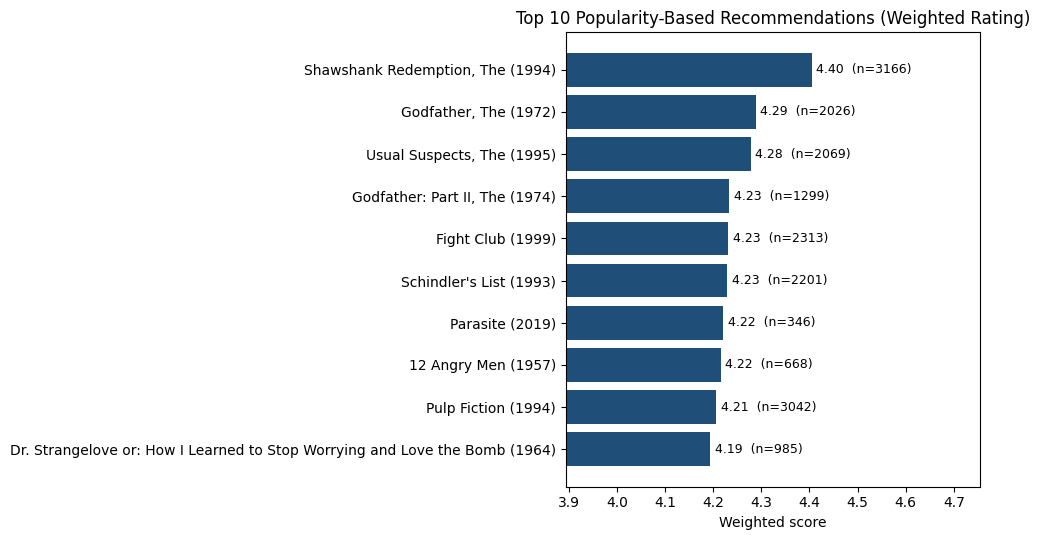

In [ ]:
plot_df = weighted_top10.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(plot_df['title'], plot_df['weighted_score'], color='#1F4E78')
for y, (s, n) in enumerate(zip(plot_df['weighted_score'], plot_df['rating_count'])):
    ax.text(s + 0.01, y, f'{s:.2f}  (n={n})', va='center', fontsize=9)
ax.set_xlim(plot_df['weighted_score'].min() - 0.3, plot_df['weighted_score'].max() + 0.35)
ax.set_xlabel('Weighted score')
ax.set_title('Top 10 Popularity-Based Recommendations (Weighted Rating)')
plt.tight_layout()
fig.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150)
plt.show()

## 12. Strengths and Limitations

**Strengths**
- Transparent and easy to explain: every score comes from two visible quantities, average rating and rating count.
- Handles the cold-start visitor: no user history is required.
- The weighted score avoids both traps seen earlier: it does not reward tiny samples, and it does not simply rank by volume.

**Limitations**
- **Not personalized.** Every user gets the identical list, ignoring genre taste, history and context.
- **Popularity bias.** Heavily rated movies are favoured, so niche or new titles are rarely surfaced, and popular titles keep collecting ratings.
- **Threshold sensitivity.** Both `MIN_RATINGS` and the percentile are policy choices that change the list (section 9.4).
- **Explicit ratings only.** Users who rate may differ from users who watch without rating, and ratings alone say nothing about why a movie was liked.
- **No diversity or freshness.** The list is static and may be dominated by one era or genre.

**Role going forward.** This list is the baseline that personalized models in later weeks must beat.